# NB-03: Torneio de Estratégias Matemáticas

**Objetivo**: Testar 9+ sistemas matemáticos de apostas sobre os 3.9M rounds e ranquear por performance.

## Estratégias testadas:
1. **Martingale** (baseline atual)
2. **Anti-Martingale (Paroli)** - dobra após ganho
3. **Fibonacci** - sequência de Fibonacci nas perdas
4. **D'Alembert** - +1 após perda, -1 após ganho
5. **Labouchère** - sistema de lista
6. **Oscar's Grind** - aumenta 1 unidade após ganho
7. **Kelly Criterion** - aposta ótima baseada em edge
8. **Fixed Fraction** - sempre X% da banca
9. **Trigger Adaptativo** - trigger dinâmico baseado em volatilidade recente

Carregados 3,964,265 registros via DuckDB
Total rounds: 3,964,265
Min: 1.00x, Max: 259.30x
--- Martingale 1/2/1/2 (T6, 2.0x) ---
Banca: R$1000 → R$1211.45 (+21.1%)
Apostas: 62 (59.7% win rate)
Profit Factor: 1.39
Max Drawdown: 11.3% (R$116.90)
Sharpe Ratio: 0.156
Max Losses Seguidas: 4
Rounds analisados: 3,964,265


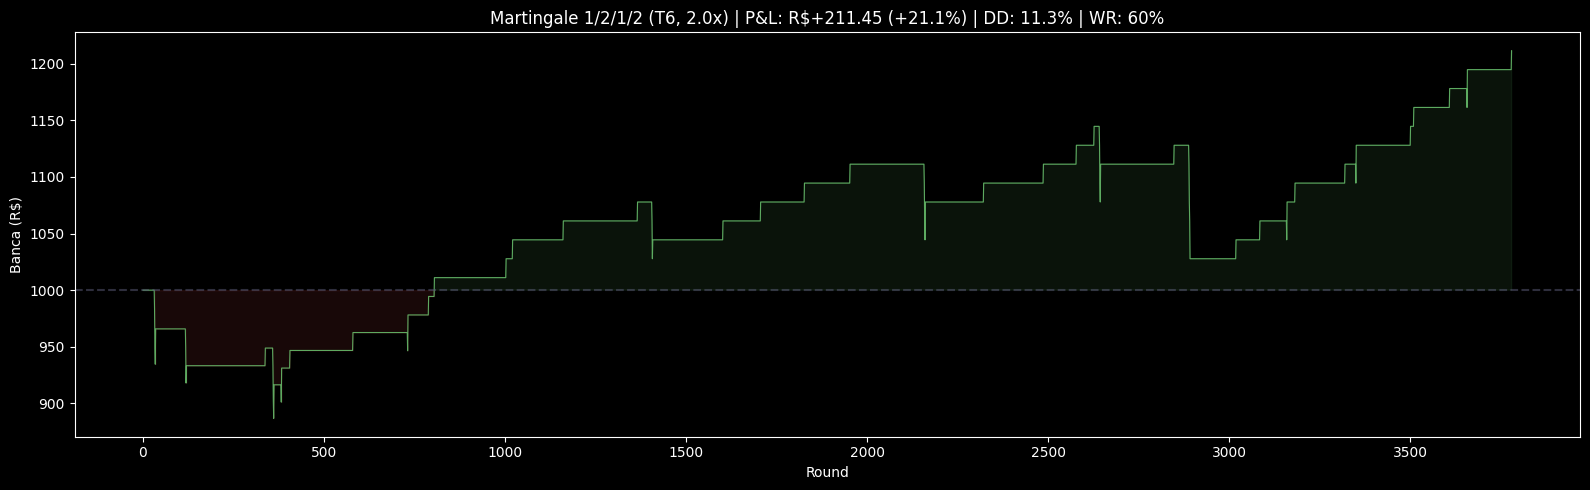

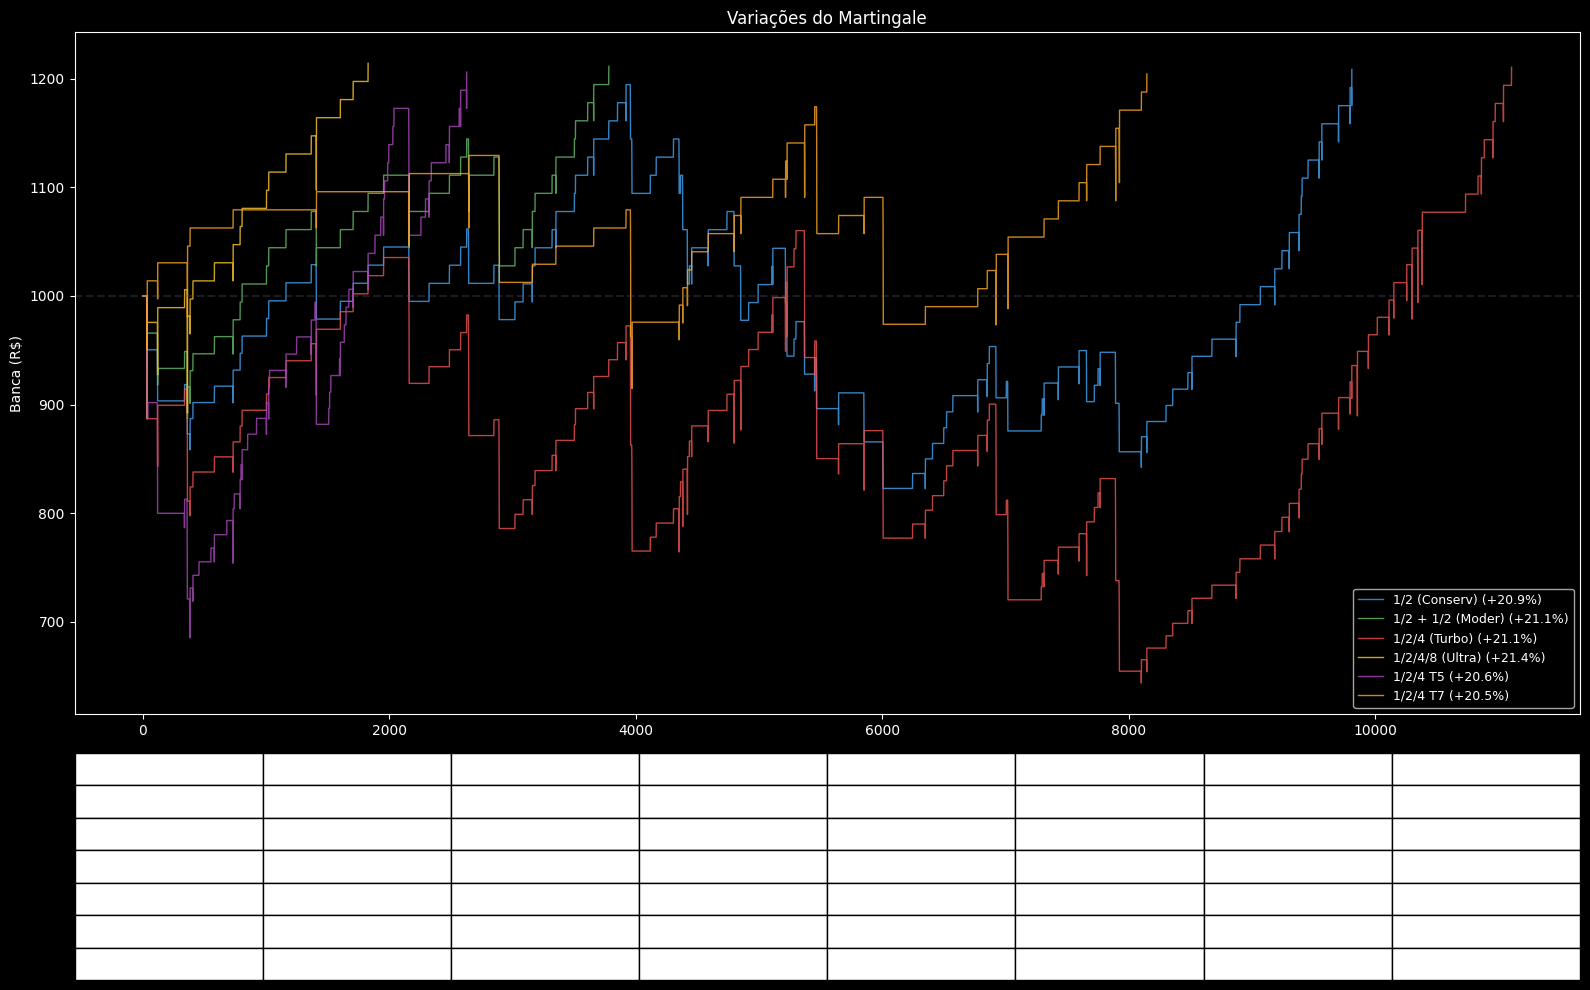

Framework do backtester pronto!

Para usar nos próximos notebooks:
  %run 12_backtester.ipynb

Ou copie as classes BettingStrategy, BankrollConfig, backtest(), plot_*
FLAT BET vs MARTINGALE (Moderado 1/2+1/2)

--- Flat Bet (T6, 2.0x) ---
Banca: R$1000 → R$1215.68 (+21.6%)
Apostas: 35 (68.6% win rate)
Profit Factor: 2.18
Max Drawdown: 5.0% (R$49.53)
Sharpe Ratio: 0.400
Max Losses Seguidas: 2
Rounds analisados: 3,964,265
  Wins: 24, Losses: 11
  Avg Win: R$16.58, Avg Loss: R$16.57

--- Martingale 1/2/1/2 (T6, 2.0x) ---
Banca: R$1000 → R$1211.45 (+21.1%)
Apostas: 62 (59.7% win rate)
Profit Factor: 1.39
Max Drawdown: 11.3% (R$116.90)
Sharpe Ratio: 0.156
Max Losses Seguidas: 4
Rounds analisados: 3,964,265
  Wins: 37, Losses: 25
  Avg Win: R$20.33, Avg Loss: R$21.63


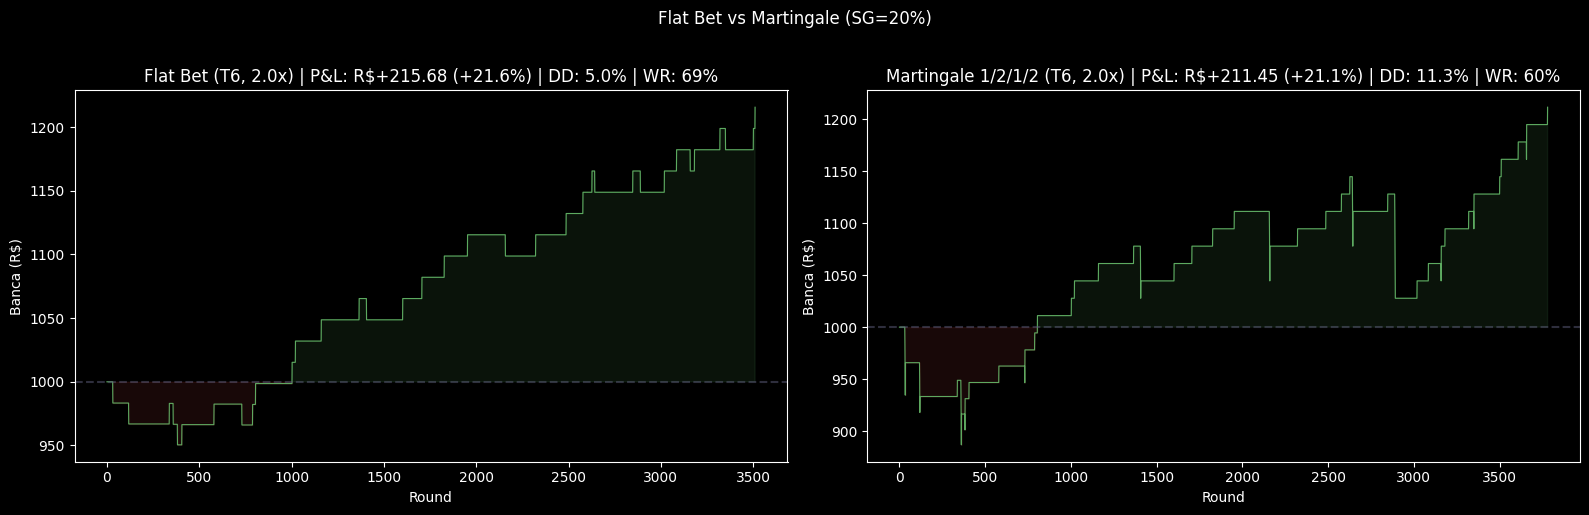

Target 1.5x: P&L=R$+206.62 | DD=17.1% | WR=68% | Bets=203 | Sharpe=0.068
Target 1.8x: P&L=R$+201.55 | DD=5.6% | WR=73% | Bets=33 | Sharpe=0.355
Target 1.95x: P&L=R$+204.16 | DD=11.6% | WR=60% | Bets=65 | Sharpe=0.148
Target 2.0x: P&L=R$+211.45 | DD=11.3% | WR=60% | Bets=62 | Sharpe=0.156
Target 2.5x: P&L=R$+207.04 | DD=8.4% | WR=53% | Bets=32 | Sharpe=0.231


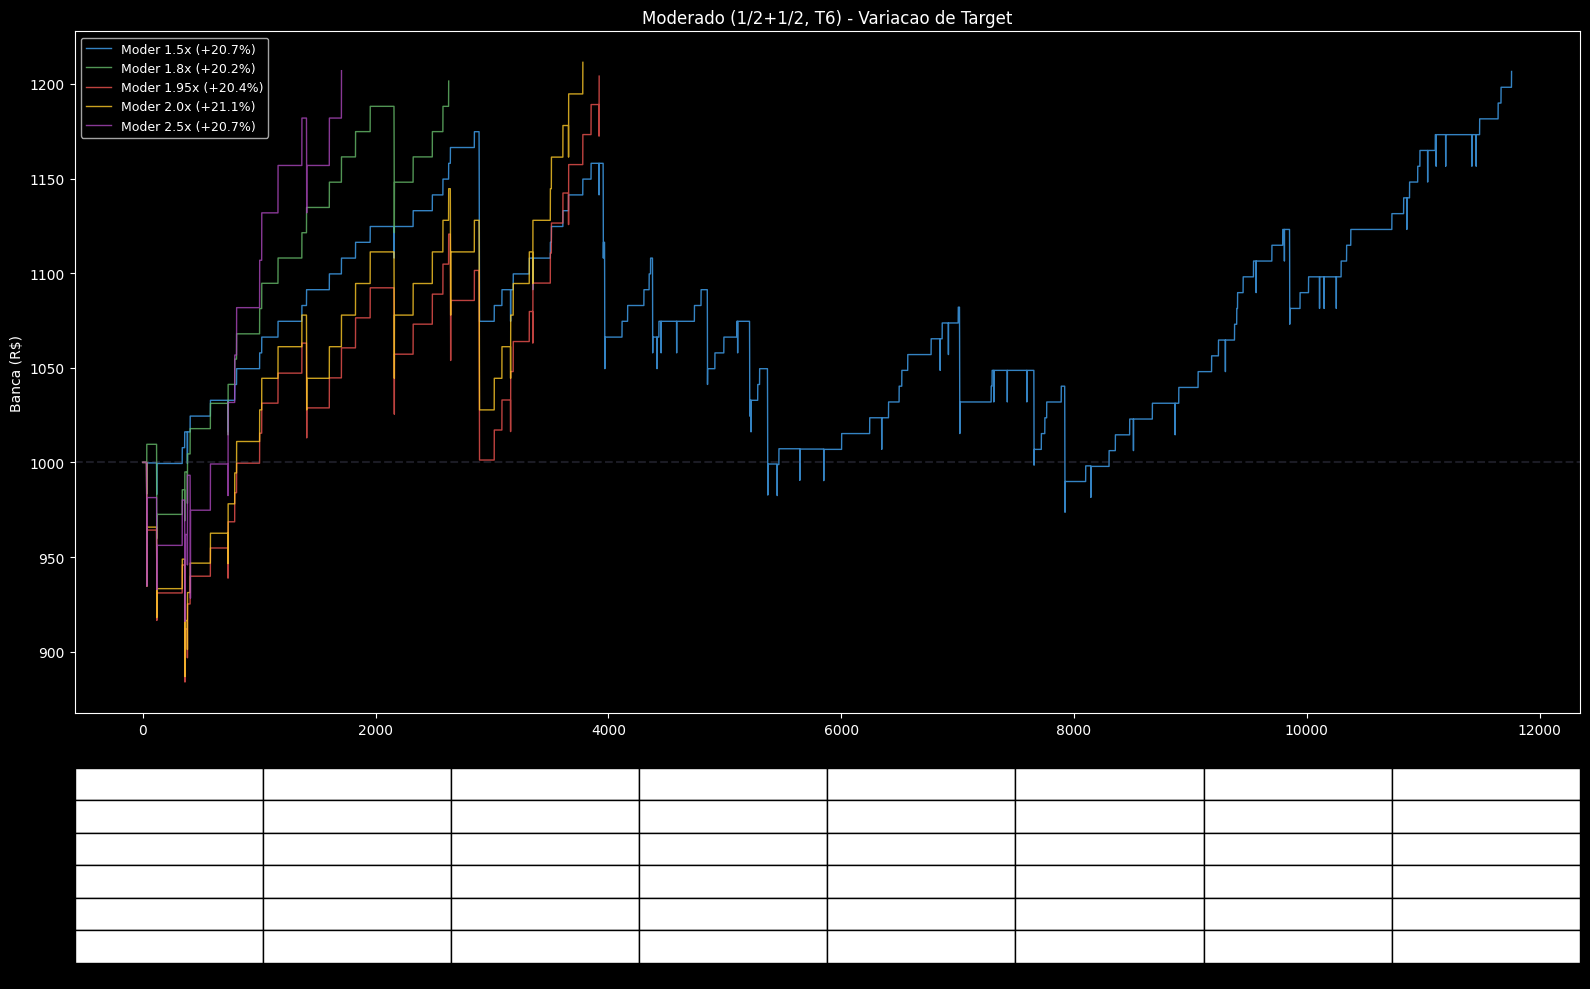

Flat Bet: Final=R$70563.52 (+6956.4%) | DD=94.0% | Bets=49399
1/2+1/2 (Moder): Final=R$211571.23 (+21057.1%) | DD=29.2% | Bets=85656
1/2/4 (Turbo): Final=R$246333.34 (+24533.3%) | DD=39.3% | Bets=81367
1/2/4/8 (Ultra): Final=R$332009.98 (+33101.0%) | DD=31.1% | Bets=85656


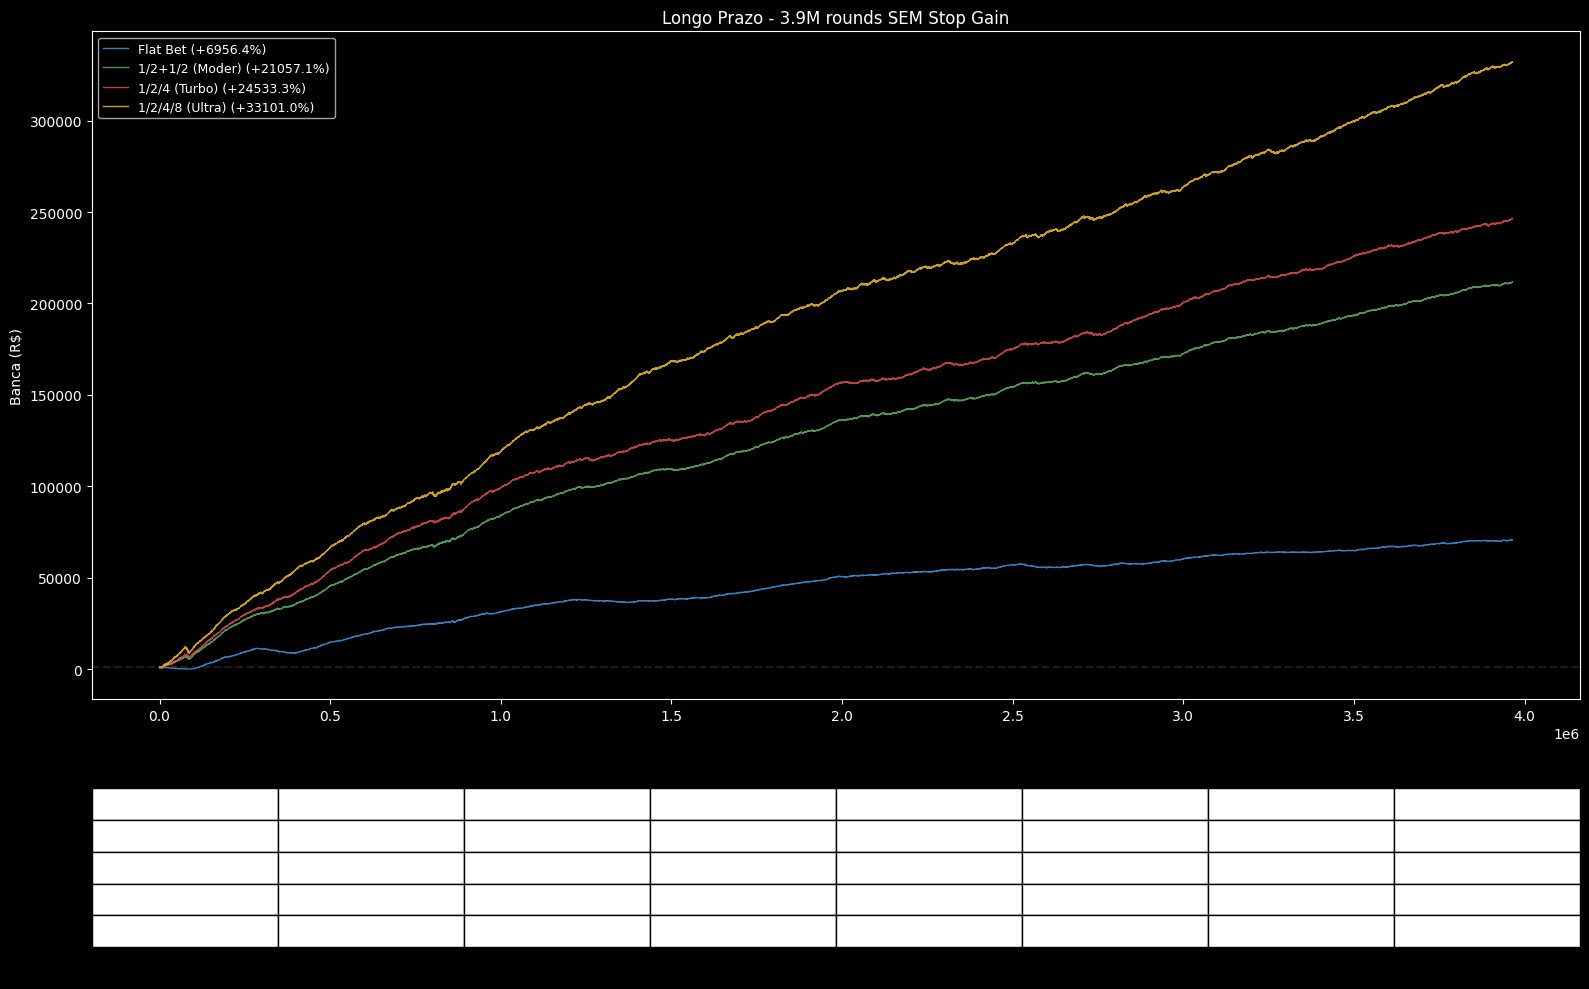

ANALISE POR SESSOES - Moderado 1/2+1/2 (1000 rounds)
Total sessoes: 3,964

Profit medio:   R$+51.12
Profit mediano: R$+65.38
Desvio padrao:  R$101.90

Sessoes positivas: 2758 (69.6%)
Sessoes negativas: 1206 (30.4%)
Sessoes neutras:   0 (0.0%)

Hit Stop Gain:  324 (8.2%)
Hit Stop Loss:  0 (0.0%)

Melhor sessao:  R$+216.54
Pior sessao:    R$-413.19

Percentis:
  P05: R$-131.86
  P10: R$-86.14
  P25: R$-18.66
  P50: R$+65.38
  P75: R$+131.29
  P90: R$+183.70
  P95: R$+200.40


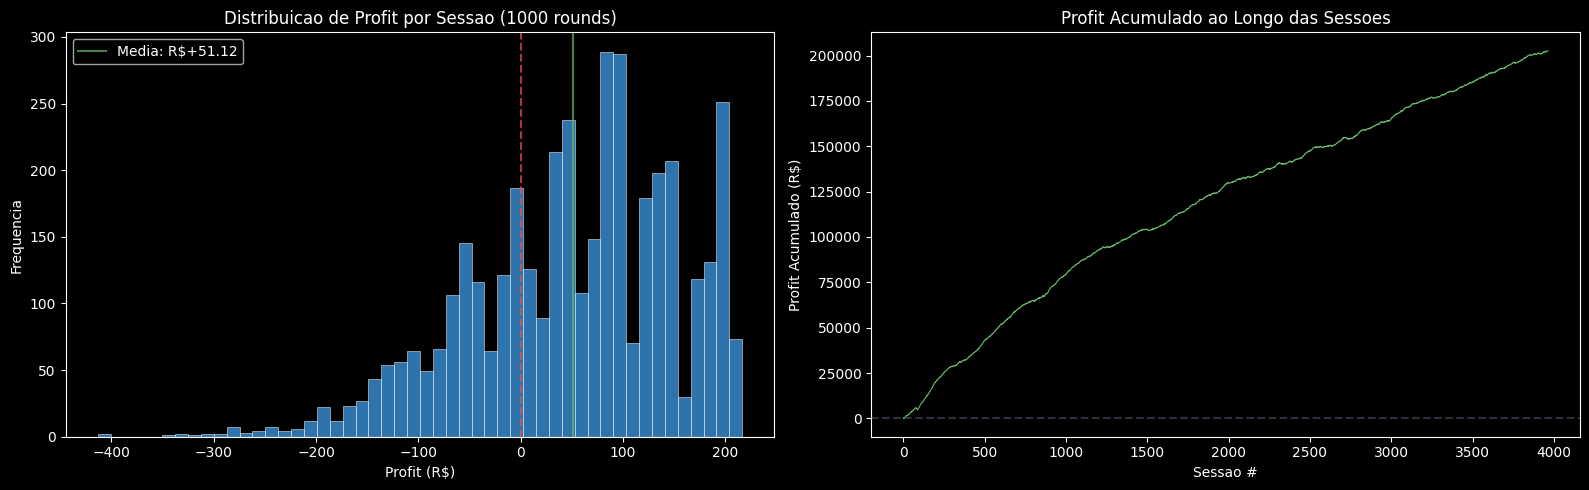

Estrategia            Media  Mediana      Std   Win%    SG%    SL%       Pior
----------------------------------------------------------------------------------
Flat Bet             +17.33   +16.13    62.74  55.3%   0.6%   0.0%    -197.52
1/2+1/2 Moder        +51.12   +65.38   101.90  69.6%   8.2%   0.0%    -413.19
1/2/4 Turbo          +57.23   +77.60   130.74  68.8%  20.0%   0.1%    -510.97
Moder 1.5x           +23.93   +32.83    58.10  69.5%   0.0%   0.0%    -318.77
Moder 1.95x          +49.90   +64.88    98.12  72.1%   5.9%   0.0%    -422.20


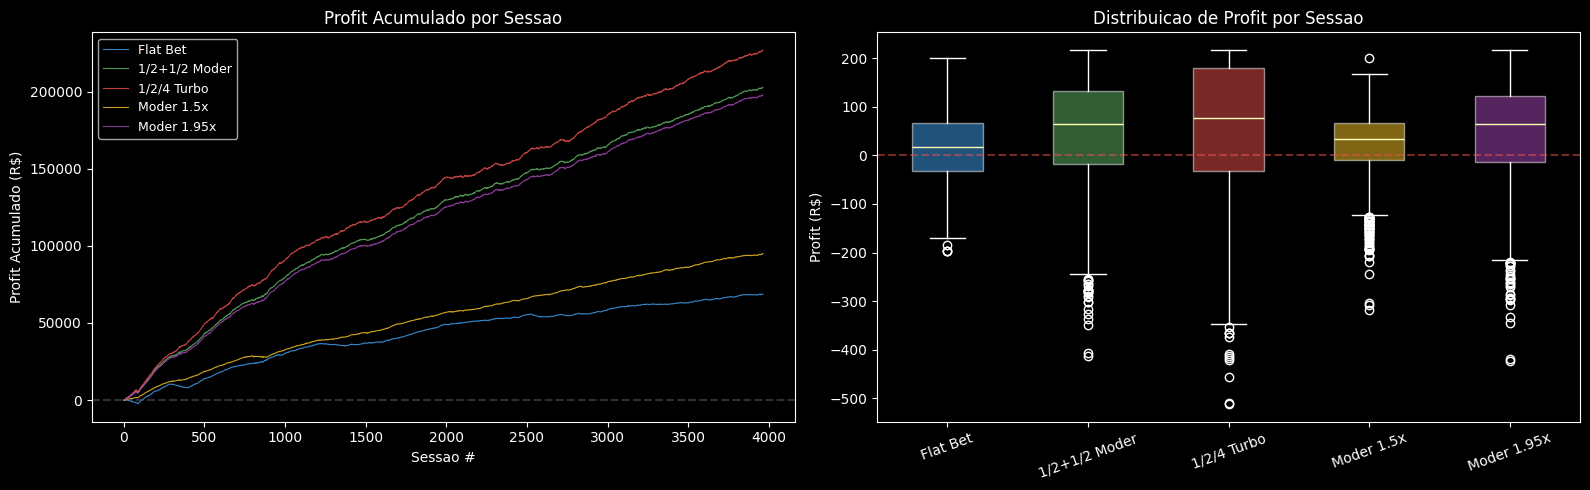

In [1]:
import sys
sys.path.insert(0, '..')

# Carregar framework do backtester
%run 12_backtester.ipynb

In [2]:
# Carregar dados
df = load_raw_data()
multipliers = df['multiplicador'].values
print(f"Dados: {len(multipliers):,} rounds")

Carregados 3,964,265 registros via DuckDB
Dados: 3,964,265 rounds


## 1. Implementação das Estratégias

In [18]:
class AntiMartingaleStrategy(BettingStrategy):
    """Paroli: dobra após WIN, reseta após LOSS.
    Lógica inversa do Martingale - captura sequências de vitórias."""

    def __init__(self, trigger=6, target=2.0, max_wins=3):
        self.trigger = trigger
        self.target = target
        self.max_wins = max_wins  # Reseta após N wins seguidos
        self.reset()

    @property
    def name(self):
        return f"Anti-Martingale (T{self.trigger}, max{self.max_wins}w)"

    def reset(self):
        self.consecutive_lows = 0
        self.triggered = False
        self.win_streak = 0
        self.current_mult = 1

    def on_round(self, multiplier, bankroll, base_bet, round_idx):
        is_low = multiplier < LOW_THRESHOLD

        if not self.triggered:
            if is_low:
                self.consecutive_lows += 1
            else:
                self.consecutive_lows = 0
            if self.consecutive_lows >= self.trigger:
                self.triggered = True
                self.current_mult = 1
                self.win_streak = 0
                return BetDecision(True, base_bet, self.target)
            return BetDecision(False)

        if multiplier >= self.target:  # WIN
            self.win_streak += 1
            if self.win_streak >= self.max_wins:
                self.triggered = False
                self.consecutive_lows = 0
                return BetDecision(False)
            self.current_mult *= 2
            return BetDecision(True, base_bet * self.current_mult, self.target)
        else:  # LOSS
            self.triggered = False
            self.consecutive_lows = 0 if not is_low else 1
            return BetDecision(False)

In [19]:
class FibonacciStrategy(BettingStrategy):
    """Fibonacci: aposta segue sequência de Fibonacci nas perdas.
    Após perda: avança na sequência. Após ganho: recua 2 posições."""

    def __init__(self, trigger=6, target=2.0, max_level=8):
        self.trigger = trigger
        self.target = target
        self.max_level = max_level
        self.fib = self._generate_fib(max_level + 2)
        self.reset()

    def _generate_fib(self, n):
        seq = [1, 1]
        for _ in range(n - 2):
            seq.append(seq[-1] + seq[-2])
        return seq

    @property
    def name(self):
        return f"Fibonacci (T{self.trigger}, max{self.max_level})"

    def reset(self):
        self.consecutive_lows = 0
        self.in_sequence = False
        self.fib_level = 0

    def on_round(self, multiplier, bankroll, base_bet, round_idx):
        is_low = multiplier < LOW_THRESHOLD

        if not self.in_sequence:
            if is_low:
                self.consecutive_lows += 1
            else:
                self.consecutive_lows = 0
            if self.consecutive_lows >= self.trigger:
                self.in_sequence = True
                self.fib_level = 0
                return BetDecision(True, base_bet * self.fib[0], self.target)
            return BetDecision(False)

        if multiplier >= self.target:  # WIN
            self.fib_level = max(0, self.fib_level - 2)
            if self.fib_level == 0:
                self.in_sequence = False
                self.consecutive_lows = 0
                return BetDecision(False)
            return BetDecision(True, base_bet * self.fib[self.fib_level], self.target)
        else:  # LOSS
            self.fib_level += 1
            if self.fib_level >= self.max_level:
                self.in_sequence = False
                self.consecutive_lows = 0
                return BetDecision(False)
            return BetDecision(True, base_bet * self.fib[self.fib_level], self.target)

In [20]:
class DAlembertStrategy(BettingStrategy):
    """D'Alembert: +1 unidade após perda, -1 após ganho.
    Progressão linear, mais conservador que Martingale."""

    def __init__(self, trigger=6, target=2.0, max_units=10):
        self.trigger = trigger
        self.target = target
        self.max_units = max_units
        self.reset()

    @property
    def name(self):
        return f"D'Alembert (T{self.trigger}, max{self.max_units}u)"

    def reset(self):
        self.consecutive_lows = 0
        self.in_sequence = False
        self.units = 1

    def on_round(self, multiplier, bankroll, base_bet, round_idx):
        is_low = multiplier < LOW_THRESHOLD

        if not self.in_sequence:
            if is_low:
                self.consecutive_lows += 1
            else:
                self.consecutive_lows = 0
            if self.consecutive_lows >= self.trigger:
                self.in_sequence = True
                self.units = 1
                return BetDecision(True, base_bet * self.units, self.target)
            return BetDecision(False)

        if multiplier >= self.target:  # WIN
            self.units = max(1, self.units - 1)
            if self.units == 1:
                self.in_sequence = False
                self.consecutive_lows = 0
                return BetDecision(False)
            return BetDecision(True, base_bet * self.units, self.target)
        else:  # LOSS
            self.units += 1
            if self.units > self.max_units:
                self.in_sequence = False
                self.consecutive_lows = 0
                return BetDecision(False)
            return BetDecision(True, base_bet * self.units, self.target)

In [21]:
class LabouchereStrategy(BettingStrategy):
    """Labouchère: mantém uma lista de números.
    Aposta = soma do primeiro + último. Win: remove ambos. Loss: adiciona soma ao final."""

    def __init__(self, trigger=6, target=2.0, initial_list=None, max_list_size=12):
        self.trigger = trigger
        self.target = target
        self.initial_list = initial_list or [1, 2, 3]
        self.max_list_size = max_list_size
        self.reset()

    @property
    def name(self):
        return f"Labouchère (T{self.trigger})"

    def reset(self):
        self.consecutive_lows = 0
        self.in_sequence = False
        self.number_list = []

    def _get_bet_units(self):
        if len(self.number_list) == 0:
            return 0
        if len(self.number_list) == 1:
            return self.number_list[0]
        return self.number_list[0] + self.number_list[-1]

    def on_round(self, multiplier, bankroll, base_bet, round_idx):
        is_low = multiplier < LOW_THRESHOLD

        if not self.in_sequence:
            if is_low:
                self.consecutive_lows += 1
            else:
                self.consecutive_lows = 0
            if self.consecutive_lows >= self.trigger:
                self.in_sequence = True
                self.number_list = self.initial_list.copy()
                units = self._get_bet_units()
                return BetDecision(True, base_bet * units, self.target)
            return BetDecision(False)

        if multiplier >= self.target:  # WIN
            if len(self.number_list) <= 2:
                self.number_list = []
            else:
                self.number_list = self.number_list[1:-1]

            if len(self.number_list) == 0:
                self.in_sequence = False
                self.consecutive_lows = 0
                return BetDecision(False)
            units = self._get_bet_units()
            return BetDecision(True, base_bet * units, self.target)
        else:  # LOSS
            lost_units = self._get_bet_units()
            self.number_list.append(lost_units)
            if len(self.number_list) > self.max_list_size:
                self.in_sequence = False
                self.consecutive_lows = 0
                return BetDecision(False)
            units = self._get_bet_units()
            return BetDecision(True, base_bet * units, self.target)

In [22]:
class OscarsGrindStrategy(BettingStrategy):
    """Oscar's Grind: aumenta 1 unidade APENAS após ganho.
    Meta: lucrar exatamente 1 unidade por ciclo. Muito conservador."""

    def __init__(self, trigger=6, target=2.0, max_units=6):
        self.trigger = trigger
        self.target = target
        self.max_units = max_units
        self.reset()

    @property
    def name(self):
        return f"Oscar's Grind (T{self.trigger})"

    def reset(self):
        self.consecutive_lows = 0
        self.in_sequence = False
        self.units = 1
        self.cycle_profit = 0  # Em unidades

    def on_round(self, multiplier, bankroll, base_bet, round_idx):
        is_low = multiplier < LOW_THRESHOLD

        if not self.in_sequence:
            if is_low:
                self.consecutive_lows += 1
            else:
                self.consecutive_lows = 0
            if self.consecutive_lows >= self.trigger:
                self.in_sequence = True
                self.units = 1
                self.cycle_profit = 0
                return BetDecision(True, base_bet, self.target)
            return BetDecision(False)

        if multiplier >= self.target:  # WIN
            self.cycle_profit += self.units * (self.target - 1)
            if self.cycle_profit >= 1:
                # Ciclo completo - lucrou 1+ unidade
                self.in_sequence = False
                self.consecutive_lows = 0
                return BetDecision(False)
            self.units = min(self.units + 1, self.max_units)
            return BetDecision(True, base_bet * self.units, self.target)
        else:  # LOSS
            self.cycle_profit -= self.units
            if abs(self.cycle_profit) > self.max_units * 3:
                self.in_sequence = False
                self.consecutive_lows = 0
                return BetDecision(False)
            # Não aumenta após perda (diferença do Martingale)
            return BetDecision(True, base_bet * self.units, self.target)

In [23]:
class KellyCriterionStrategy(BettingStrategy):
    """Kelly Criterion: aposta = (p*b - q) / b onde:
    p = prob. de ganho, q = prob. de perda, b = odds (target - 1).
    Usa estimativa rolling da prob. real.
    Usa base_bet como referência (respeita compound settings)."""

    def __init__(self, trigger=6, target=2.0, window=500, fraction=0.5):
        self.trigger = trigger
        self.target = target
        self.window = window
        self.fraction = fraction  # Fração do Kelly (0.5 = half-Kelly)
        self.reset()

    @property
    def name(self):
        return f"Kelly {self.fraction:.0%} (T{self.trigger}, w{self.window})"

    def reset(self):
        self.consecutive_lows = 0
        self.history = []

    def on_round(self, multiplier, bankroll, base_bet, round_idx):
        is_low = multiplier < LOW_THRESHOLD
        self.history.append(multiplier)

        if is_low:
            self.consecutive_lows += 1
        else:
            self.consecutive_lows = 0

        if self.consecutive_lows >= self.trigger:
            self.consecutive_lows = 0  # Reseta para não apostar toda rodada

            # Calcular Kelly baseado na prob. real recente
            recent = self.history[-self.window:] if len(self.history) >= self.window else self.history
            p_win = np.mean(np.array(recent) >= self.target)
            b = self.target - 1  # Odds
            q = 1 - p_win

            kelly_pct = (p_win * b - q) / b if b > 0 else 0
            kelly_pct = max(0, min(kelly_pct * self.fraction, 0.10))  # Cap 10%

            if kelly_pct > 0:
                # Usar base_bet como referência para respeitar compound settings
                bet = max(base_bet, base_bet * kelly_pct / 0.0167)
                bet = min(bet, bankroll * 0.10)  # Nunca mais que 10% da banca
                return BetDecision(True, bet, self.target)

        return BetDecision(False)

In [24]:
class FixedFractionStrategy(BettingStrategy):
    """Aposta fixa: sempre X unidades da aposta base.
    Sem progressão, sem martingale. Puramente gestão de risco.
    Usa base_bet (respeita compound settings do backtest engine)."""

    def __init__(self, trigger=6, target=2.0, multiplier=1.0):
        self.trigger = trigger
        self.target = target
        self.multiplier = multiplier  # Multiplicador da base_bet
        self.reset()

    @property
    def name(self):
        return f"Fixed {self.multiplier:.0f}x base (T{self.trigger})"

    def reset(self):
        self.consecutive_lows = 0

    def on_round(self, multiplier, bankroll, base_bet, round_idx):
        is_low = multiplier < LOW_THRESHOLD

        if is_low:
            self.consecutive_lows += 1
        else:
            self.consecutive_lows = 0

        if self.consecutive_lows >= self.trigger:
            self.consecutive_lows = 0
            bet = base_bet * self.multiplier
            return BetDecision(True, bet, self.target)

        return BetDecision(False)

In [25]:
class AdaptiveTriggerStrategy(BettingStrategy):
    """Trigger adaptativo: ajusta o trigger baseado na volatilidade recente.
    Alta volatilidade (muitos LOWs) → trigger mais alto.
    Baixa volatilidade → trigger mais baixo."""

    def __init__(self, base_trigger=6, target=2.0, window=200,
                 min_trigger=4, max_trigger=10, pattern=None):
        self.base_trigger = base_trigger
        self.target = target
        self.window = window
        self.min_trigger = min_trigger
        self.max_trigger = max_trigger
        self.pattern = pattern or [1, 2, 4]
        self.reset()

    @property
    def name(self):
        return f"Adaptativo (base T{self.base_trigger}, w{self.window})"

    def reset(self):
        self.consecutive_lows = 0
        self.in_sequence = False
        self.current_dobra = 0
        self.low_history = []
        self.current_trigger = self.base_trigger

    def _update_trigger(self):
        if len(self.low_history) < self.window:
            return
        recent = self.low_history[-self.window:]
        pct_low = np.mean(recent)

        # Se mais LOWs que o normal → jogar mais conservador
        if pct_low > 0.58:
            self.current_trigger = min(self.base_trigger + 2, self.max_trigger)
        elif pct_low > 0.55:
            self.current_trigger = self.base_trigger + 1
        elif pct_low < 0.50:
            self.current_trigger = max(self.base_trigger - 1, self.min_trigger)
        else:
            self.current_trigger = self.base_trigger

    def on_round(self, multiplier, bankroll, base_bet, round_idx):
        is_low = multiplier < LOW_THRESHOLD
        self.low_history.append(1 if is_low else 0)
        self._update_trigger()

        if not self.in_sequence:
            if is_low:
                self.consecutive_lows += 1
            else:
                self.consecutive_lows = 0

            if self.consecutive_lows >= self.current_trigger:
                self.in_sequence = True
                self.current_dobra = 0
                mult = self.pattern[0]
                return BetDecision(True, base_bet * mult, self.target)
            return BetDecision(False)

        if multiplier >= self.target:  # WIN
            self.in_sequence = False
            self.consecutive_lows = 0
            return BetDecision(False)
        else:  # LOSS
            self.current_dobra += 1
            if self.current_dobra >= len(self.pattern):
                self.in_sequence = False
                self.consecutive_lows = 0
                return BetDecision(False)
            mult = self.pattern[self.current_dobra]
            return BetDecision(True, base_bet * mult, self.target)

## 2. Torneio Principal (Target 2.0x)

In [11]:
config = BankrollConfig(
    initial_bankroll=1000.0,
    base_bet_pct=0.0167,  # banca/6 ≈ 1.67%
    compound=False,
    stop_gain_pct=10.0,   # Sem stop gain para comparar livre
    stop_loss_pct=1.0,    # 100% stop loss
)

strategies = [
    MartingaleStrategy(trigger=6, target=2.0, pattern=[1, 2, 4]),
    MartingaleStrategy(trigger=6, target=2.0, pattern=[1, 2, 1, 2]),
    AntiMartingaleStrategy(trigger=6, target=2.0, max_wins=3),
    FibonacciStrategy(trigger=6, target=2.0, max_level=8),
    DAlembertStrategy(trigger=6, target=2.0, max_units=10),
    LabouchereStrategy(trigger=6, target=2.0),
    OscarsGrindStrategy(trigger=6, target=2.0),
    KellyCriterionStrategy(trigger=6, target=2.0, fraction=0.5),
    FixedFractionStrategy(trigger=6, target=2.0, multiplier=1.0),
    AdaptiveTriggerStrategy(base_trigger=6, target=2.0, pattern=[1, 2, 4]),
]

results = []
for strat in strategies:
    print(f"Testando: {strat.name}...", end=" ")
    r = backtest(strat, multipliers, config)
    results.append(r)
    print(f"P&L: R${r.total_profit:+.0f} | WR: {r.win_rate:.0f}% | DD: {r.max_drawdown_pct:.1f}%")

print(f"\nTorneio completo: {len(results)} estratégias testadas")

Testando: Martingale 1/2/4 (T6, 2.0x)... P&L: R$+245333 | WR: 55% | DD: 39.3%
Testando: Martingale 1/2/1/2 (T6, 2.0x)... P&L: R$+210571 | WR: 55% | DD: 29.2%
Testando: Anti-Martingale (T6, max3w)... P&L: R$-1000 | WR: 52% | DD: 100.0%
Testando: Fibonacci (T6, max8)... P&L: R$+184510 | WR: 54% | DD: 58.4%
Testando: D'Alembert (T6, max10u)... P&L: R$-1000 | WR: 50% | DD: 100.0%
Testando: Labouchère (T6)... P&L: R$-1000 | WR: 48% | DD: 100.0%
Testando: Oscar's Grind (T6)... P&L: R$-1000 | WR: 50% | DD: 100.0%
Testando: Kelly 50% (T6, w500)... P&L: R$+2129 | WR: 61% | DD: 8.8%
Testando: Fixed 1x base (T6)... P&L: R$+69564 | WR: 54% | DD: 94.0%
Testando: Adaptativo (base T6, w200)... P&L: R$+177347 | WR: 55% | DD: 26.5%

Torneio completo: 10 estratégias testadas


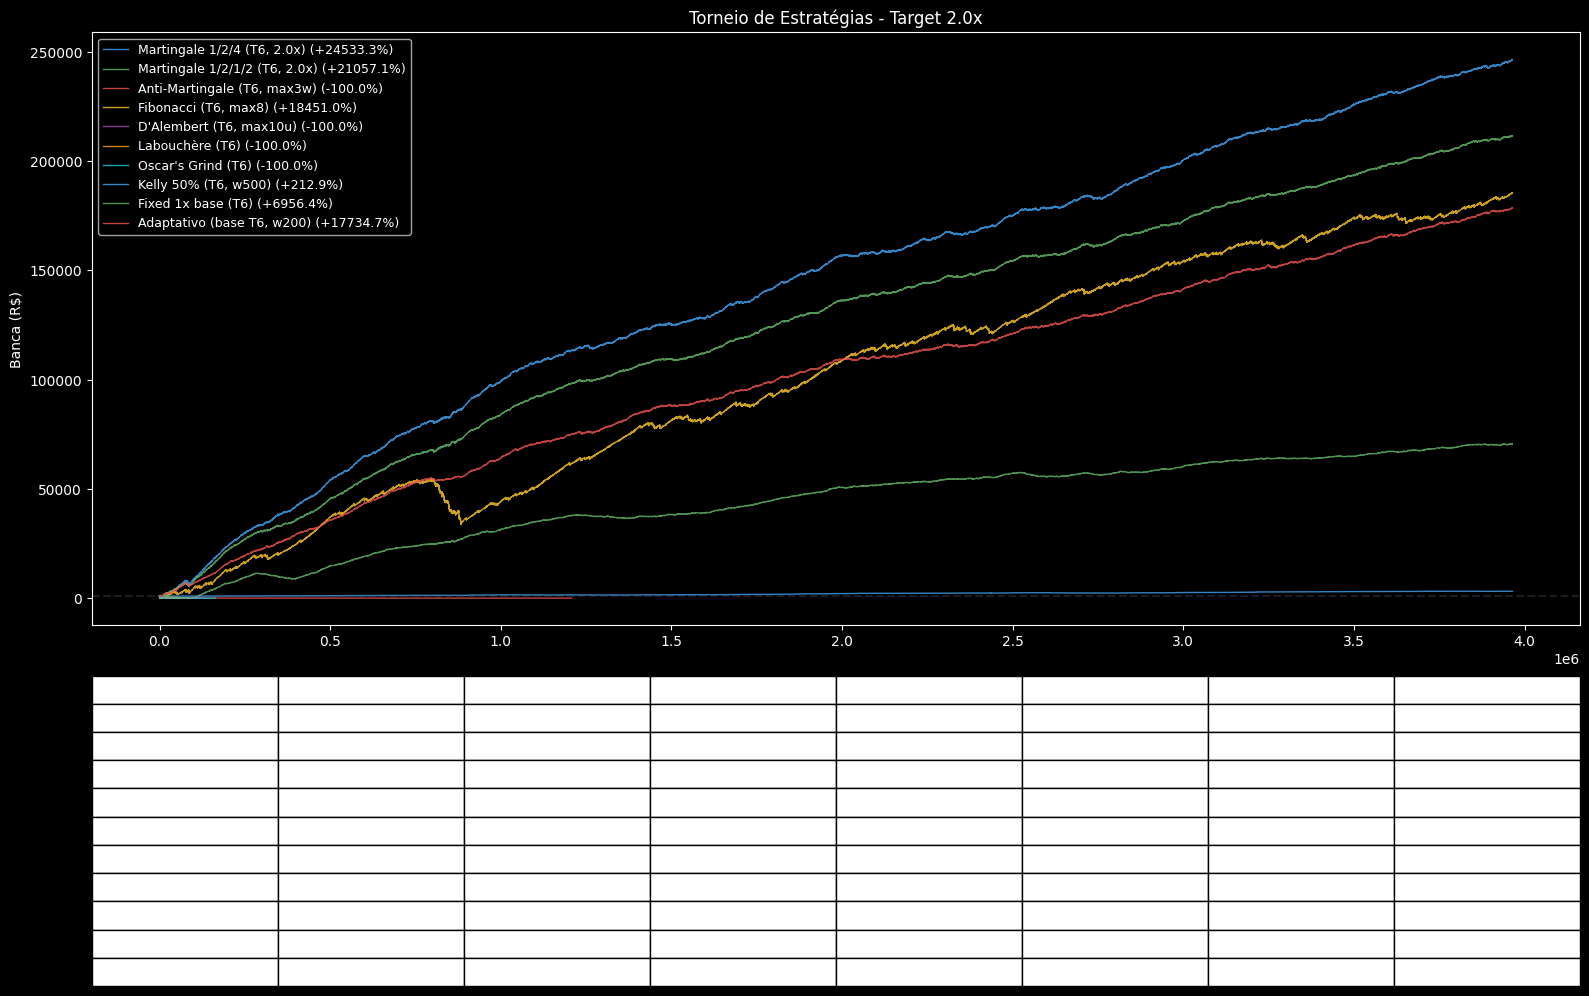

In [12]:
# Comparação visual
plot_comparison(results, 'Torneio de Estratégias - Target 2.0x')

## 3. Variação de Targets (1.5x, 2.0x, 2.5x, 3.0x)

In [13]:
targets = [1.5, 2.0, 2.5, 3.0]
target_results = {}

for target in targets:
    print(f"\n=== Target {target}x ===")
    strats = [
        MartingaleStrategy(trigger=6, target=target, pattern=[1, 2, 4]),
        FibonacciStrategy(trigger=6, target=target),
        DAlembertStrategy(trigger=6, target=target),
        KellyCriterionStrategy(trigger=6, target=target, fraction=0.5),
        AdaptiveTriggerStrategy(base_trigger=6, target=target, pattern=[1, 2, 4]),
    ]

    target_results[target] = []
    for strat in strats:
        r = backtest(strat, multipliers, config)
        target_results[target].append(r)
        print(f"  {strat.name:40s} | P&L: R${r.total_profit:+8.0f} | Sharpe: {r.sharpe_ratio:+.3f}")


=== Target 1.5x ===
  Martingale 1/2/4 (T6, 1.5x)              | P&L: R$ +105729 | Sharpe: +0.087
  Fibonacci (T6, max8)                     | P&L: R$  +83650 | Sharpe: +0.074
  D'Alembert (T6, max10u)                  | P&L: R$  +70607 | Sharpe: +0.031
  Kelly 50% (T6, w500)                     | P&L: R$  +24211 | Sharpe: +0.107
  Adaptativo (base T6, w200)               | P&L: R$  +76009 | Sharpe: +0.092

=== Target 2.0x ===
  Martingale 1/2/4 (T6, 2.0x)              | P&L: R$ +245333 | Sharpe: +0.095
  Fibonacci (T6, max8)                     | P&L: R$ +184510 | Sharpe: +0.036
  D'Alembert (T6, max10u)                  | P&L: R$   -1000 | Sharpe: -0.020
  Kelly 50% (T6, w500)                     | P&L: R$   +2129 | Sharpe: +0.223
  Adaptativo (base T6, w200)               | P&L: R$ +177347 | Sharpe: +0.100

=== Target 2.5x ===
  Martingale 1/2/4 (T6, 2.5x)              | P&L: R$ +298353 | Sharpe: +0.076
  Fibonacci (T6, max8)                     | P&L: R$   -1000 | Sharpe: -0.002
 

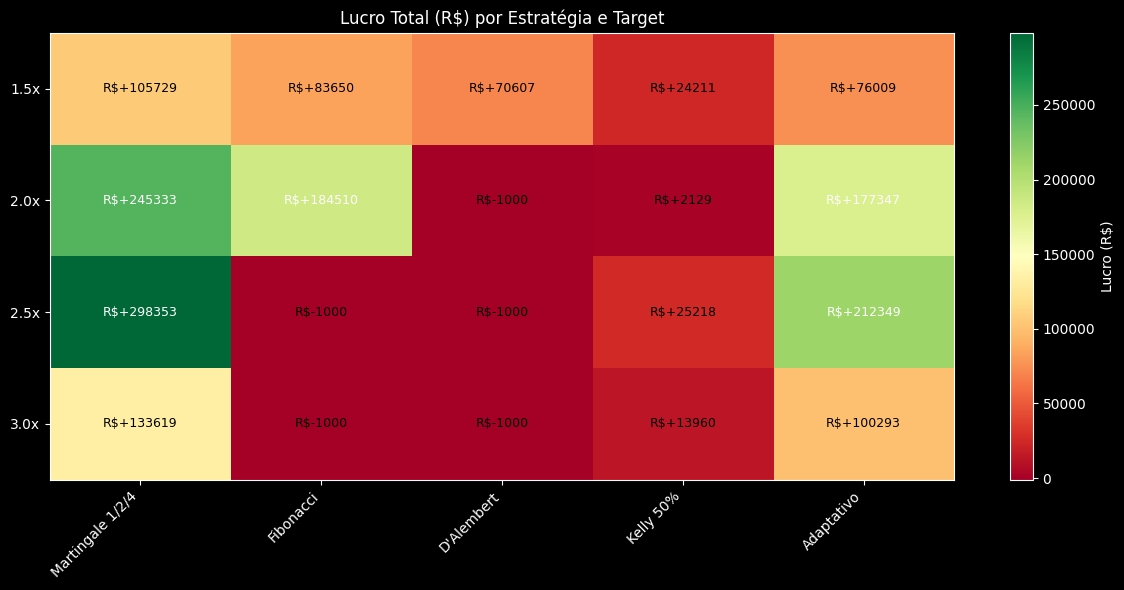

In [14]:
# Heatmap: Lucro por Estratégia x Target
fig, ax = plt.subplots(figsize=(12, 6))

strat_names = [r.strategy_name for r in target_results[2.0]]
data = []
for target in targets:
    row = [r.total_profit for r in target_results[target]]
    data.append(row)

data = np.array(data)
im = ax.imshow(data, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(strat_names)))
ax.set_xticklabels([s.split('(')[0].strip() for s in strat_names], rotation=45, ha='right')
ax.set_yticks(range(len(targets)))
ax.set_yticklabels([f'{t}x' for t in targets])
ax.set_title('Lucro Total (R$) por Estratégia e Target')

for i in range(len(targets)):
    for j in range(len(strat_names)):
        ax.text(j, i, f'R${data[i,j]:+.0f}', ha='center', va='center',
                fontsize=9, color='black' if abs(data[i,j]) < data.max()/2 else 'white')

plt.colorbar(im, ax=ax, label='Lucro (R$)')
plt.tight_layout()
plt.show()

## 4. Variação de Triggers (4, 5, 6, 7, 8)

T4: P&L=R$-1000 | Apostas=27440 | WR=47% | DD=100.0%
T5: P&L=R$+192160 | Apostas=161064 | WR=49% | DD=64.0%
T6: P&L=R$+245333 | Apostas=81367 | WR=55% | DD=39.3%
T7: P&L=R$+131433 | Apostas=36542 | WR=57% | DD=19.0%
T8: P&L=R$+57313 | Apostas=15860 | WR=56% | DD=12.7%


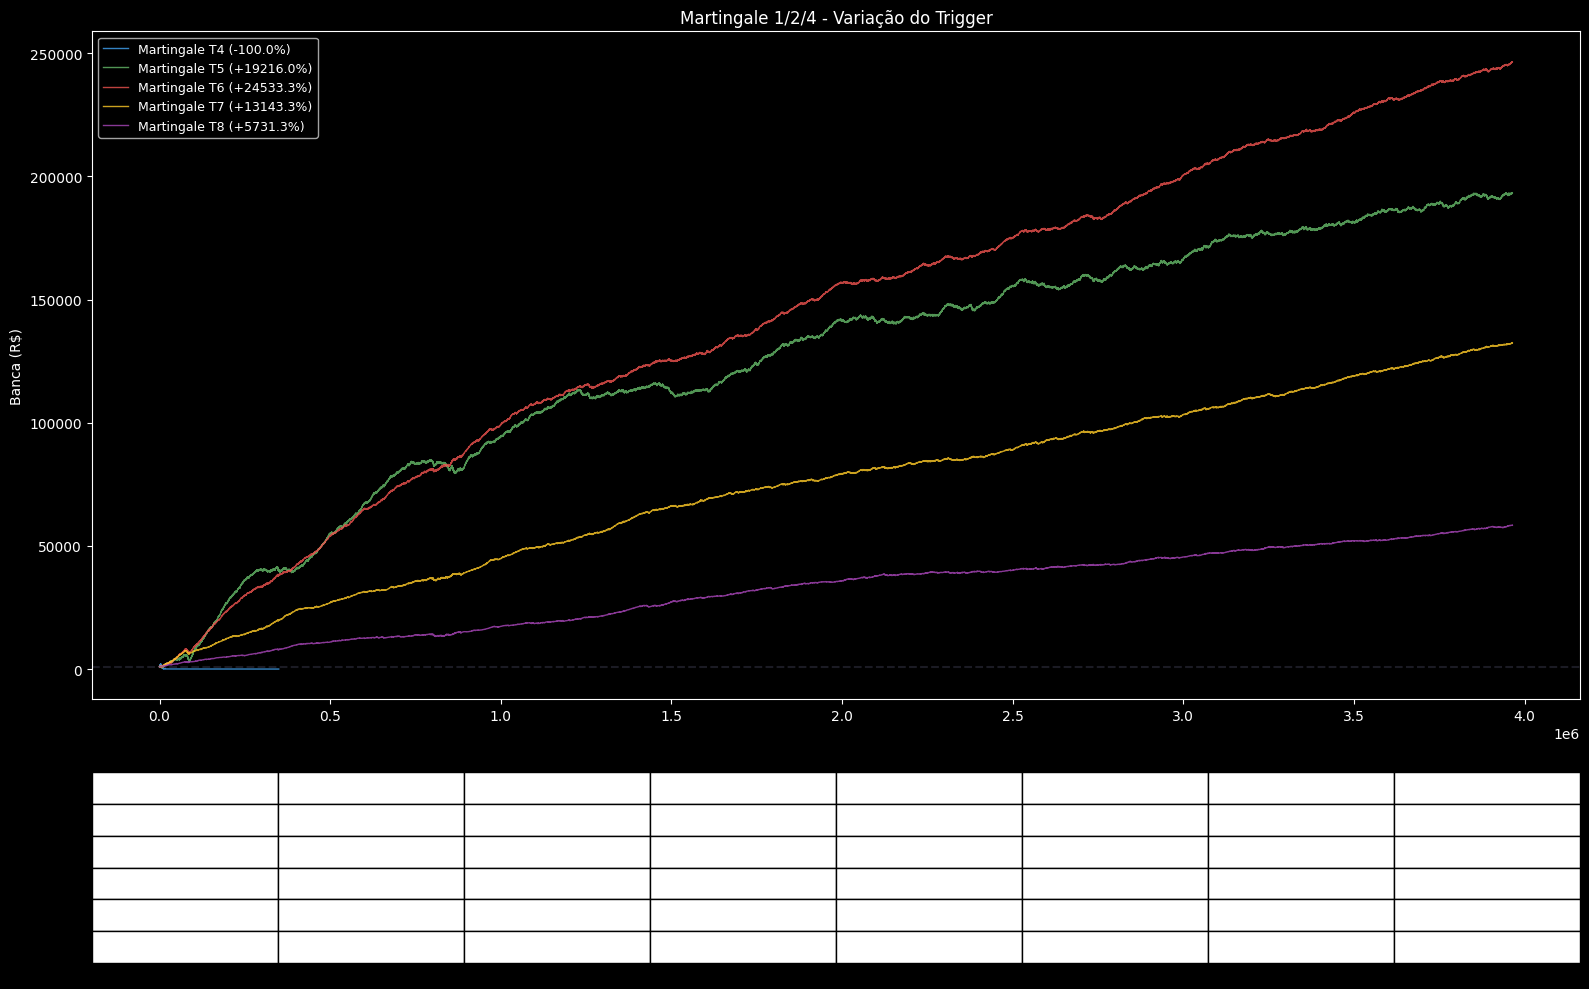

In [15]:
triggers = [4, 5, 6, 7, 8]

# Testar martingale 1/2/4 com diferentes triggers
trigger_results = []
for t in triggers:
    strat = MartingaleStrategy(trigger=t, target=2.0, pattern=[1, 2, 4])
    r = backtest(strat, multipliers, config)
    r.strategy_name = f"Martingale T{t}"
    trigger_results.append(r)
    print(f"T{t}: P&L=R${r.total_profit:+.0f} | Apostas={r.total_bets} | WR={r.win_rate:.0f}% | DD={r.max_drawdown_pct:.1f}%")

plot_comparison(trigger_results, 'Martingale 1/2/4 - Variação do Trigger')

## 5. Ranking Final

In [16]:
# Ranking por Sharpe Ratio (melhor relação risco/retorno)
all_results = sorted(results, key=lambda r: r.sharpe_ratio, reverse=True)

print("=" * 80)
print("RANKING POR SHARPE RATIO (risco ajustado)")
print("=" * 80)
print(f"{'#':>3} {'Estratégia':40s} {'Sharpe':>8} {'Lucro':>10} {'WR':>6} {'DD%':>7} {'PF':>6}")
print("-" * 80)

for i, r in enumerate(all_results, 1):
    print(f"{i:>3} {r.strategy_name:40s} {r.sharpe_ratio:>+8.3f} "
          f"R${r.total_profit:>+8.0f} {r.win_rate:>5.0f}% {r.max_drawdown_pct:>6.1f}% "
          f"{r.profit_factor:>5.2f}")

RANKING POR SHARPE RATIO (risco ajustado)
  # Estratégia                                 Sharpe      Lucro     WR     DD%     PF
--------------------------------------------------------------------------------
  1 Kelly 50% (T6, w500)                       +0.223 R$   +2129    61%    8.8%  1.56
  2 Martingale 1/2/1/2 (T6, 2.0x)              +0.106 R$ +210571    55%   29.2%  1.25
  3 Adaptativo (base T6, w200)                 +0.100 R$ +177347    55%   26.5%  1.26
  4 Martingale 1/2/4 (T6, 2.0x)                +0.095 R$ +245333    55%   39.3%  1.25
  5 Fixed 1x base (T6)                         +0.086 R$  +69564    54%   94.0%  1.19
  6 Fibonacci (T6, max8)                       +0.036 R$ +184510    54%   58.4%  1.12
  7 Anti-Martingale (T6, max3w)                -0.015 R$   -1000    52%  100.0%  0.80
  8 D'Alembert (T6, max10u)                    -0.020 R$   -1000    50%  100.0%  0.90
  9 Oscar's Grind (T6)                         -0.031 R$   -1000    50%  100.0%  0.68
 10 Labouchère (